# Modelagem, avaliação e explicabilidade — FemHealth Clinical AI

Este notebook consolida a trajetória metodológica de um projeto acadêmico de classificação de padrões do dataset WDBC. O objetivo é documentar as decisões de modelagem, avaliação e explicabilidade sem afirmar validade clínica.

O fluxo separa desenvolvimento e teste final para reduzir vazamento de dados. As decisões de modelo, calibração e threshold foram tomadas antes da abertura do holdout final.

## Arquitetura metodológica

Dados públicos → validação do contrato → desenvolvimento → comparação de modelos → ajuste e calibração → seleção congelada → avaliação final → artefato → API e interface

O notebook usa funções já implementadas no pacote `femhealth` e lê artefatos persistidos. Ele não reimplementa pipelines, grids, métricas finais ou a explicabilidade global.

## Ambiente e importações

In [1]:
import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt  # noqa: F401
import pandas as pd
from IPython.display import display

from femhealth.data import (
    WDBC_CLASS_DISTRIBUTION,
    WDBC_CLASS_NAMES,
    WDBC_FEATURE_COUNT,
    WDBC_FEATURE_NAMES,
    load_wdbc_data,
)
from femhealth.data_split import split_development_test
from femhealth.final_selection import (
    SELECTED_CALIBRATION,
    SELECTED_MODEL,
    SELECTED_THRESHOLD,
    SELECTED_VARIANT,
)
from femhealth.model_evaluation import (
    BENIGN_LABEL,
    MALIGNANT_LABEL,
    evaluate_baseline_candidates,
)
from femhealth.model_tuning import tune_selected_candidates
from femhealth.probability_analysis import run_probability_analysis

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

pd.set_option("display.max_columns", 40)
pd.set_option("display.max_colwidth", 140)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")

## Dataset e contrato

O WDBC é carregado por `load_wdbc_data()`, que valida o contrato automatizado do pacote. A exploração detalhada de variáveis permanece em `notebooks/01_exploracao_wdbc.ipynb`.

In [2]:
X, y = load_wdbc_data()

class_counts = y.value_counts().sort_index().to_dict()
dataset_summary = pd.DataFrame(
    [
        {"item": "registros", "valor": len(X)},
        {"item": "features", "valor": X.shape[1]},
        {"item": "valores nulos", "valor": int(X.isna().sum().sum())},
        {"item": "ordem canônica preservada", "valor": list(X.columns) == WDBC_FEATURE_NAMES},
        {"item": "contrato de distribuição", "valor": class_counts == WDBC_CLASS_DISTRIBUTION},
    ]
)
class_distribution_total = (
    y.value_counts()
    .sort_index()
    .rename_axis("classe")
    .reset_index(name="quantidade")
)
class_distribution_total["nome"] = class_distribution_total["classe"].map(WDBC_CLASS_NAMES)
class_distribution_total["percentual"] = class_distribution_total["quantidade"] / len(y)
feature_contract = pd.DataFrame(
    {
        "posição": range(1, WDBC_FEATURE_COUNT + 1),
        "feature": WDBC_FEATURE_NAMES,
    }
)

display(dataset_summary)
display(class_distribution_total)
display(feature_contract)

,item,valor
0,registros,569
1,features,30
2,valores nulos,0
3,ordem canônica preservada,True
4,contrato de distribuição,True


,classe,quantidade,nome,percentual
0,0,212,malignant,0.3726
1,1,357,benign,0.6274


,posição,feature
0,1,mean radius
1,2,mean texture
2,3,mean perimeter
3,4,mean area
4,5,mean smoothness
5,6,mean compactness
6,7,mean concavity
7,8,mean concave points
8,9,mean symmetry
9,10,mean fractal dimension


## Separação desenvolvimento/teste

A divisão estratificada reproduz o protocolo congelado do projeto. O teste final é listado aqui apenas para documentar o desenho experimental; depois as variáveis do holdout são removidas do ambiente do notebook.

In [3]:
X_development, X_test, y_development, y_test = split_development_test(X, y)

split_rows = []
for name, target in [("desenvolvimento", y_development), ("teste final", y_test)]:
    counts = target.value_counts().sort_index()
    split_rows.append(
        {
            "conjunto": name,
            "registros": len(target),
            "malignos": int(counts[MALIGNANT_LABEL]),
            "benignos": int(counts[BENIGN_LABEL]),
            "proporção maligna": counts[MALIGNANT_LABEL] / len(target),
            "proporção benigna": counts[BENIGN_LABEL] / len(target),
        }
    )

split_summary = pd.DataFrame(split_rows)
display(split_summary)

del X_test, y_test

,conjunto,registros,malignos,benignos,proporção maligna,proporção benigna
0,desenvolvimento,455,170,285,0.3736,0.6264
1,teste final,114,42,72,0.3684,0.6316


## Benchmark dos cinco modelos

A comparação baseline usa validação cruzada estratificada somente no conjunto de desenvolvimento. A tabela abaixo é ordenada apenas para leitura, sem criar uma nova decisão de seleção.

In [4]:
baseline_results = evaluate_baseline_candidates(X_development, y_development)

baseline_columns = [
    "model",
    "accuracy_mean",
    "balanced_accuracy_mean",
    "precision_malignant_mean",
    "recall_malignant_mean",
    "f1_malignant_mean",
    "specificity_benign_mean",
    "roc_auc_malignant_mean",
    "average_precision_malignant_mean",
    "false_negative_malignant",
    "false_positive_malignant",
]
baseline_display = (
    baseline_results[baseline_columns]
    .sort_values(
        ["recall_malignant_mean", "specificity_benign_mean"],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(baseline_display)

,model,accuracy_mean,balanced_accuracy_mean,precision_malignant_mean,recall_malignant_mean,f1_malignant_mean,specificity_benign_mean,roc_auc_malignant_mean,average_precision_malignant_mean,false_negative_malignant,false_positive_malignant
0,logistic_regression,0.9780,0.9753,0.9770,0.9647,0.9703,0.9860,0.9959,0.9954,6,4
1,random_forest,0.9626,0.9619,0.9440,0.9588,0.9506,0.9649,0.9896,0.9874,7,10
2,svm,0.9692,0.9659,0.9649,0.9529,0.9583,0.9789,0.9956,0.9944,8,6
3,knn,0.9626,0.9559,0.9707,0.9294,0.9490,0.9825,0.9882,0.9787,12,5
4,decision_tree,0.9165,0.9179,0.8632,0.9235,0.8919,0.9123,0.9179,0.8260,13,25


Regressão Logística aparece como um baseline forte, enquanto SVM e Random Forest permanecem competitivos. O recall maligno é relevante neste estudo acadêmico porque falsos negativos são um erro crítico para análise de triagem. Essa leitura não constitui conclusão clínica.

## Ajuste de hiperparâmetros

O ajuste dos três candidatos selecionados reutiliza a função pública `tune_selected_candidates()`. Os espaços de busca permanecem definidos no pacote, não no notebook.

In [5]:
tuning_summary, _fitted_searches = tune_selected_candidates(X_development, y_development)

tuning_columns = [
    "model",
    "refit_metric",
    "best_params",
    "accuracy_mean",
    "balanced_accuracy_mean",
    "precision_malignant_mean",
    "recall_malignant_mean",
    "f1_malignant_mean",
    "specificity_benign_mean",
    "roc_auc_malignant_mean",
    "average_precision_malignant_mean",
]

display(tuning_summary[tuning_columns])

,model,refit_metric,best_params,accuracy_mean,balanced_accuracy_mean,precision_malignant_mean,recall_malignant_mean,f1_malignant_mean,specificity_benign_mean,roc_auc_malignant_mean,average_precision_malignant_mean
0,logistic_regression,recall_malignant,"{'model__C': 0.1, 'model__class_weight': 'balanced', 'model__l1_ratio': 1.0, 'model__solver': 'liblinear'}",0.9648,0.9672,0.9348,0.9765,0.9545,0.9579,0.9921,0.9912
1,random_forest,recall_malignant,"{'model__class_weight': 'balanced', 'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__n_est...",0.9604,0.9625,0.9281,0.9706,0.9484,0.9544,0.9916,0.9896
2,svm,recall_malignant,"{'model__C': 1.0, 'model__class_weight': 'balanced', 'model__gamma': 'scale', 'model__kernel': 'rbf'}",0.9736,0.9730,0.9603,0.9706,0.9650,0.9754,0.9963,0.9951


O refit foi orientado por recall maligno, mas as demais métricas também foram mantidas para evitar uma escolha baseada em um único número. KNN e Árvore de Decisão permaneceram no benchmark e não foram ajustados nesta etapa.

## Calibração e análise de threshold

A análise de probabilidades compara variantes nativas e calibradas por sigmoid usando apenas previsões out-of-fold no desenvolvimento. A tabela completa de thresholds não é exibida para manter o notebook objetivo.

In [6]:
probability_results = run_probability_analysis(X_development, y_development)

probability_quality = probability_results["probability_quality"]
operating_points = probability_results["operating_points"]

display(probability_quality)
display(operating_points)

,variant,brier_score,log_loss,roc_auc_malignant,average_precision_malignant
0,logistic_regression_native,0.0378,0.1519,0.9922,0.9909
1,logistic_regression_sigmoid,0.0256,0.0975,0.9917,0.9904
2,random_forest_native,0.0325,0.1209,0.9914,0.9887
3,random_forest_sigmoid,0.0277,0.1067,0.9909,0.9885
4,svm_sigmoid,0.0210,0.0802,0.9949,0.9936


,variant,threshold,accuracy,balanced_accuracy,precision_malignant,recall_malignant,f1_malignant,specificity_benign,true_malignant,false_negative_malignant,false_positive_malignant,true_benign
0,logistic_regression_native,0.5300,0.9648,0.9660,0.9375,0.9706,0.9538,0.9614,165,5,11,274
1,logistic_regression_sigmoid,0.4100,0.9648,0.9660,0.9375,0.9706,0.9538,0.9614,165,5,11,274
2,random_forest_native,0.5000,0.9604,0.9625,0.9270,0.9706,0.9483,0.9544,165,5,13,272
3,random_forest_sigmoid,0.4200,0.9626,0.9654,0.9274,0.9765,0.9513,0.9544,166,4,13,272
4,svm_sigmoid,0.5100,0.9758,0.9748,0.9649,0.9706,0.9677,0.9789,165,5,6,279


Brier Score e log loss avaliam qualidade probabilística. A restrição de recall maligno mínimo foi usada como critério acadêmico para pontos operacionais provisórios. Nenhuma recomendação clínica foi produzida nessa etapa.

## Seleção congelada

A seleção abaixo foi congelada antes da consulta ao teste final.

In [7]:
selection_summary = pd.DataFrame(
    [
        {"item": "variante selecionada", "valor": SELECTED_VARIANT},
        {"item": "modelo", "valor": SELECTED_MODEL},
        {"item": "calibração", "valor": SELECTED_CALIBRATION},
        {"item": "threshold maligno", "valor": SELECTED_THRESHOLD},
        {"item": "classe maligna", "valor": MALIGNANT_LABEL},
        {"item": "classe benigna", "valor": BENIGN_LABEL},
    ]
)

display(selection_summary)

,item,valor
0,variante selecionada,svm_sigmoid
1,modelo,svm
2,calibração,sigmoid
3,threshold maligno,0.5100
4,classe maligna,0
5,classe benigna,1


O SVM calibrado por sigmoid foi escolhido pelo equilíbrio nas estimativas de desenvolvimento: recall maligno dentro da restrição, menos falsos positivos que a Regressão Logística no ponto operacional, e qualidade probabilística geral consistente. A decisão foi tomada antes do teste final.

## Resultado final do holdout

Esta seção lê apenas o resumo final já persistido em `reports/results/final_holdout_summary.json`. O notebook não recalcula a avaliação final.

In [8]:
final_summary_path = PROJECT_ROOT / "reports/results/final_holdout_summary.json"
final_summary = json.loads(final_summary_path.read_text(encoding="utf-8"))

assert final_summary["selected_variant"] == "svm_sigmoid"
assert final_summary["threshold"] == 0.51
assert final_summary["test_sample_count"] == 114

final_metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "precision_malignant",
    "recall_malignant",
    "f1_malignant",
    "specificity_benign",
    "roc_auc_malignant",
    "average_precision_malignant",
    "brier_score",
    "log_loss",
]
final_metrics_table = pd.DataFrame(
    [{"métrica": metric, "valor": final_summary[metric]} for metric in final_metric_columns]
)
confusion_matrix_pt = pd.DataFrame(
    [
        [final_summary["true_malignant"], final_summary["false_negative_malignant"]],
        [final_summary["false_positive_malignant"], final_summary["true_benign"]],
    ],
    index=["Real: maligno", "Real: benigno"],
    columns=["Previsto: maligno", "Previsto: benigno"],
)

display(final_metrics_table)
display(confusion_matrix_pt)

,métrica,valor
0,accuracy,0.9737
1,balanced_accuracy,0.9742
2,precision_malignant,0.9535
3,recall_malignant,0.9762
4,f1_malignant,0.9647
5,specificity_benign,0.9722
6,roc_auc_malignant,0.9940
7,average_precision_malignant,0.9918
8,brier_score,0.0278
9,log_loss,0.0950


,Previsto: maligno,Previsto: benigno
Real: maligno,41,1
Real: benigno,2,70


O desempenho final foi coerente com as estimativas de desenvolvimento, mas o teste contém apenas 42 casos malignos. Nesse tamanho de amostra, cada erro altera bastante o recall. O resultado não substitui validação externa e não estabelece validade clínica.

## Artefato persistido

Esta seção lê os metadados do artefato e calcula o SHA-256 do arquivo Joblib por bytes, sem carregar o estimador e sem executar inferência.

In [9]:
artifact_metadata_path = PROJECT_ROOT / "artifacts/model/femhealth_svm_sigmoid.metadata.json"
artifact_model_path = PROJECT_ROOT / "artifacts/model/femhealth_svm_sigmoid.joblib"
artifact_metadata = json.loads(artifact_metadata_path.read_text(encoding="utf-8"))
calculated_sha256 = hashlib.sha256(artifact_model_path.read_bytes()).hexdigest()

assert calculated_sha256 == artifact_metadata["model_sha256"]
assert artifact_metadata["selected_variant"] == SELECTED_VARIANT
assert artifact_metadata["threshold"] == SELECTED_THRESHOLD
assert artifact_metadata["training_sample_count"] == len(X_development)
assert artifact_metadata["feature_count"] == WDBC_FEATURE_COUNT

artifact_summary = pd.DataFrame(
    [
        {"item": "versão do artefato", "valor": artifact_metadata["artifact_version"]},
        {"item": "Scikit-learn", "valor": artifact_metadata["scikit_learn_version"]},
        {"item": "registros de treinamento", "valor": artifact_metadata["training_sample_count"]},
        {"item": "features", "valor": artifact_metadata["feature_count"]},
        {"item": "threshold", "valor": artifact_metadata["threshold"]},
        {"item": "hash validado", "valor": calculated_sha256},
        {"item": "holdout no treinamento", "valor": "não"},
    ]
)

display(artifact_summary)

,item,valor
0,versão do artefato,1.0.0
1,Scikit-learn,1.9.0
2,registros de treinamento,455
3,features,30
4,threshold,0.5100
5,hash validado,cc43cec3ba58c5a4950217e80c8b286b0e7db501ff663ba9be9f91df1f4b05b5
6,holdout no treinamento,não


## Explicabilidade global

A explicabilidade global é lida dos artefatos já salvos. O notebook não recalcula a importância de permutação.

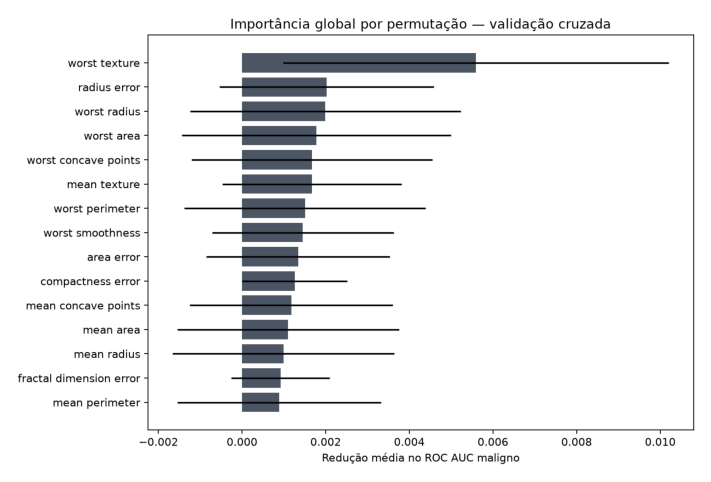

,fold,train_sample_count,validation_sample_count,train_malignant_count,train_benign_count,validation_malignant_count,validation_benign_count,baseline_roc_auc
0,1,364,91,136,228,34,57,0.9892
1,2,364,91,136,228,34,57,0.9979
2,3,364,91,136,228,34,57,0.9974
3,4,364,91,136,228,34,57,0.9979
4,5,364,91,136,228,34,57,0.9990


,métrica,valor
0,média ROC AUC,0.9963
1,desvio-padrão ROC AUC,0.0040


,rank,feature_name,mean_importance,std_importance,positive_fraction
0,1,worst texture,0.0056,0.0046,0.8800
1,2,radius error,0.0020,0.0026,0.7000
2,3,worst radius,0.0020,0.0032,0.6800
3,4,worst area,0.0018,0.0032,0.6800
4,5,worst concave points,0.0017,0.0029,0.6400
5,6,mean texture,0.0017,0.0021,0.7400
6,7,worst perimeter,0.0015,0.0029,0.6600
7,8,worst smoothness,0.0015,0.0022,0.7600
8,9,area error,0.0013,0.0022,0.6600
9,10,compactness error,0.0013,0.0013,0.7400


In [10]:
explainability_summary_path = PROJECT_ROOT / (
    "reports/explainability/permutation_importance_summary.csv"
)
explainability_fold_scores_path = PROJECT_ROOT / (
    "reports/explainability/permutation_importance_fold_scores.csv"
)
explainability_metadata_path = PROJECT_ROOT / (
    "reports/explainability/permutation_importance_metadata.json"
)
explainability_plot_path = PROJECT_ROOT / "reports/explainability/permutation_importance_top15.png"

explainability_summary = pd.read_csv(explainability_summary_path)
explainability_fold_scores = pd.read_csv(explainability_fold_scores_path)
explainability_metadata = json.loads(explainability_metadata_path.read_text(encoding="utf-8"))

assert explainability_metadata["holdout_used"] is False
assert explainability_metadata["detail_row_count"] == 1500
assert explainability_metadata["cv_splits"] == 5
assert explainability_metadata["permutation_repeats"] == 10

fold_roc_auc_summary = pd.DataFrame(
    [
        {
            "métrica": "média ROC AUC",
            "valor": explainability_fold_scores["baseline_roc_auc"].mean(),
        },
        {
            "métrica": "desvio-padrão ROC AUC",
            "valor": explainability_fold_scores["baseline_roc_auc"].std(),
        },
    ]
)
top15_importance = explainability_summary[
    ["rank", "feature_name", "mean_importance", "std_importance", "positive_fraction"]
].head(15)

plot_image = plt.imread(explainability_plot_path)
figure, axis = plt.subplots(figsize=(9, 6))
axis.imshow(plot_image)
axis.axis("off")
plt.show()

display(explainability_fold_scores)
display(fold_roc_auc_summary)
display(top15_importance)

`worst texture` teve a maior importância média. Ainda assim, várias diferenças entre posições são pequenas diante da variabilidade observada, e barras de erro próximas ou atravessando zero exigem cautela. Variáveis correlacionadas podem dividir importância entre si. Importância preditiva não é causalidade nem relevância clínica.

## Discussão crítica

### Pontos fortes

- contrato rígido do dataset;
- pipelines contra vazamento;
- validação cruzada;
- holdout congelado;
- calibração;
- threshold definido antes do teste;
- artefato versionado;
- testes automatizados;
- separação API/Streamlit;
- explicabilidade sem reutilizar o holdout.

### Limitações

- dataset pequeno;
- origem histórica e específica do WDBC;
- ausência de validação externa;
- apenas dados tabulares;
- ausência de contexto clínico completo;
- correlação entre features;
- incerteza das importâncias;
- ausência de estudo prospectivo;
- não substitui avaliação médica.

### Uso responsável

A saída é uma classificação acadêmica. Ela não constitui diagnóstico, não recomenda tratamento e não substitui decisão de profissionais qualificados.

## Conclusão

O projeto comparou cinco modelos, ajustou os três candidatos mais promissores e congelou um SVM RBF calibrado por sigmoid antes da avaliação final. O resultado no holdout foi registrado em artefatos, o estimador foi persistido, e a inferência foi disponibilizada por FastAPI e Streamlit. A explicabilidade global por permutação complementa o relatório técnico, com cautela sobre correlação, variabilidade e ausência de validade clínica. Próximos passos acadêmicos incluem documentação final, apresentação e discussão responsável das limitações.